# Modeling — Credit Card Fraud Detection

**Goal:** Train and evaluate multiple fraud detection models with threshold optimization and cost-sensitive evaluation.

### Sections
1. Setup & Load Data
2. Build Pipeline Helper
3. Baseline — Logistic Regression
4. Random Forest
5. XGBoost
6. Isolation Forest (Anomaly Detection)
7. Model Comparison
8. Threshold Optimization
9. Cost-Sensitive Evaluation
10. MLflow Tracking & Save Best Model

---
## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, sys, json, joblib

warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('..'))

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    average_precision_score, precision_recall_curve,
    f1_score, recall_score, precision_score,
    roc_auc_score, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline
import mlflow
import mlflow.sklearn

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

FRAUD_COLOR  = '#ef4444'
LEGIT_COLOR  = '#3b82f6'
RANDOM_STATE = 42
TARGET       = 'Class'

# Business cost parameters
# Missing a fraud costs much more than a false alarm
COST_FN = 100   # cost of missing one fraud transaction
COST_FP = 1     # cost of one false alarm (investigation)

print('Libraries loaded')

Libraries loaded


In [2]:
train_df = pd.read_csv('../data/processed/train.csv')
test_df  = pd.read_csv('../data/processed/test.csv')

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]
X_test  = test_df.drop(columns=[TARGET])
y_test  = test_df[TARGET]

with open('../models/feature_names.json') as f:
    feature_info = json.load(f)

numeric_cols     = feature_info['numeric']
categorical_cols = feature_info['categorical']

print(f'Train: {X_train.shape} | Fraud rate: {y_train.mean():.4%}')
print(f'Test:  {X_test.shape}  | Fraud rate: {y_test.mean():.4%}')

Train: (226980, 33) | Fraud rate: 0.1665%
Test:  (56746, 33)  | Fraud rate: 0.1674%


---
## 2. Build Pipeline Helper

In [3]:
def build_preprocessor():
    numeric_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  RobustScaler()),
    ])
    categorical_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    return ColumnTransformer([
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols),
    ])


def build_pipeline(classifier, sampler=None):
    steps = [('preprocessor', build_preprocessor())]
    if sampler is not None:
        steps.append(('sampler', sampler))
        return ImbPipeline(steps + [('classifier', classifier)])
    steps.append(('classifier', classifier))
    return Pipeline(steps)


def evaluate(pipeline, X_test, y_test, threshold=0.5, name='Model'):
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        'PR-AUC':    round(average_precision_score(y_test, y_prob), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'F1':        round(f1_score(y_test, y_pred, zero_division=0), 4),
    }
    print(f'\n--- {name} (threshold={threshold:.2f}) ---')
    for k, v in metrics.items():
        print(f'  {k:12s}: {v}')
    return metrics, y_pred, y_prob


def optimize_threshold(y_true, y_prob, cost_fn=COST_FN, cost_fp=COST_FP):
    """Find threshold that minimises total business cost."""
    thresholds   = np.linspace(0.01, 0.99, 300)
    best_t       = 0.5
    best_cost    = float('inf')
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        fn     = ((y_true == 1) & (y_pred == 0)).sum()
        fp     = ((y_true == 0) & (y_pred == 1)).sum()
        cost   = fn * cost_fn + fp * cost_fp
        if cost < best_cost:
            best_cost = cost
            best_t    = t
    return best_t, best_cost


def plot_evaluation(y_test, y_pred, y_prob, title):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Legitimate', 'Fraud'],
        cmap='Blues', ax=axes[0]
    )
    axes[0].set_title('Confusion Matrix', fontweight='bold')
    RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], name=title)
    axes[1].plot([0,1],[0,1],'k--', linewidth=1)
    axes[1].set_title('ROC Curve', fontweight='bold')
    PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[2], name=title)
    axes[2].set_title('Precision-Recall Curve', fontweight='bold')
    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


print('Helper functions ready')

Helper functions ready


---
## 3. Baseline — Logistic Regression

Using class_weight='balanced' as an alternative to resampling for the baseline.


--- Logistic Regression (threshold=0.50) ---
  PR-AUC      : 0.6911
  ROC-AUC     : 0.9655
  Recall      : 0.8737
  Precision   : 0.055
  F1          : 0.1035


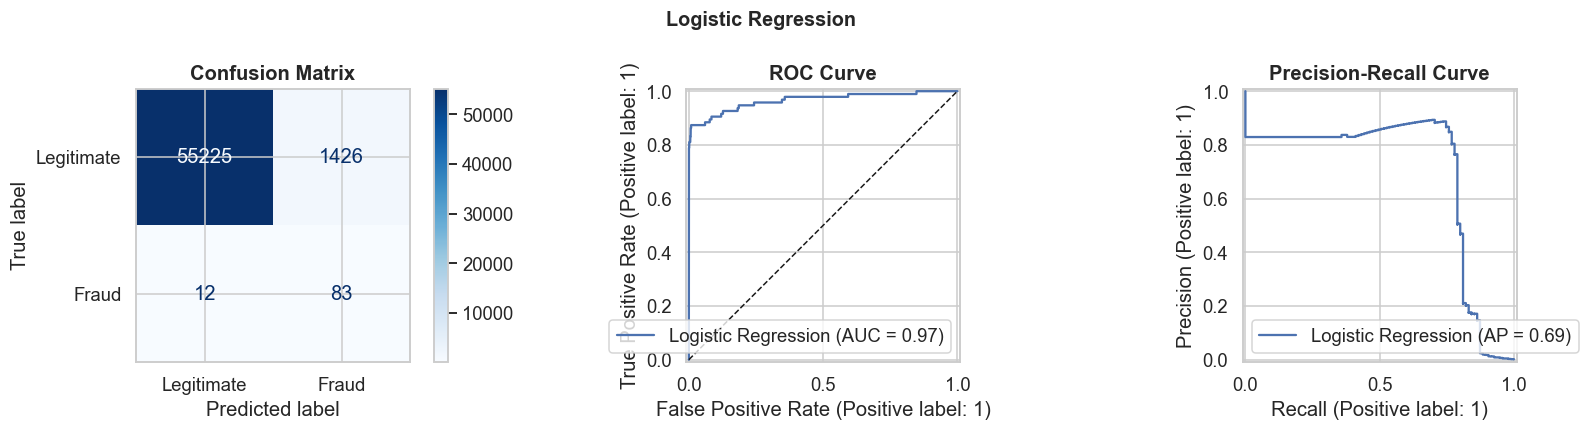

In [4]:
lr_pipeline = build_pipeline(
    LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    sampler=SMOTE(random_state=RANDOM_STATE)
)
lr_pipeline.fit(X_train, y_train)
lr_metrics, lr_pred, lr_prob = evaluate(lr_pipeline, X_test, y_test,
                                         name='Logistic Regression')
plot_evaluation(y_test, lr_pred, lr_prob, 'Logistic Regression')

---
## 4. Random Forest


--- Random Forest (threshold=0.50) ---
  PR-AUC      : 0.8303
  ROC-AUC     : 0.9669
  Recall      : 0.7895
  Precision   : 0.9375
  F1          : 0.8571


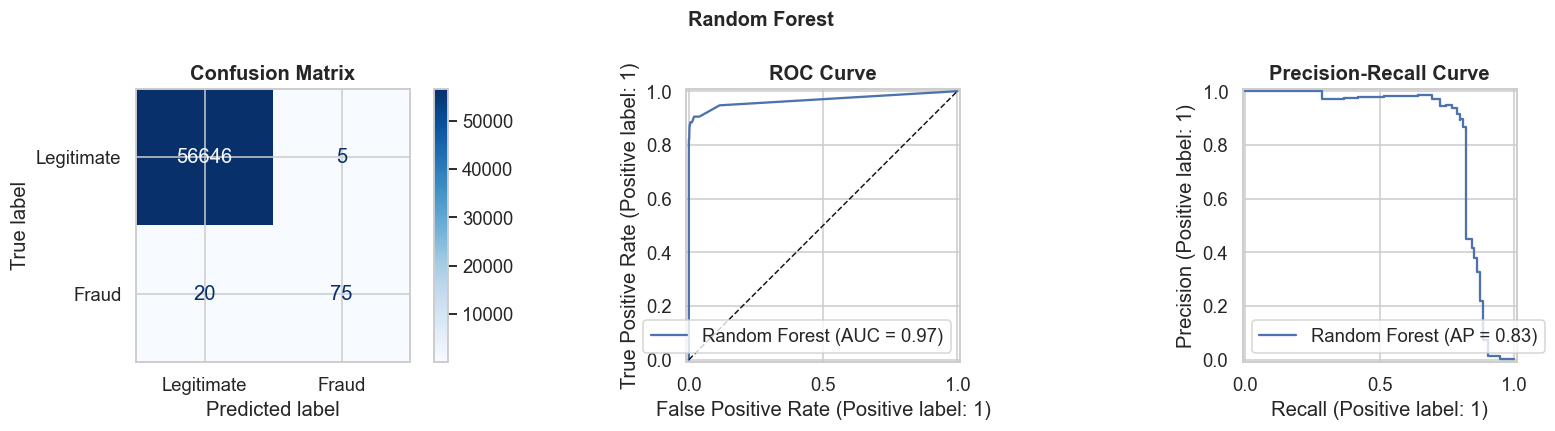

In [5]:
rf_pipeline = build_pipeline(
    RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    sampler=SMOTE(random_state=RANDOM_STATE)
)
rf_pipeline.fit(X_train, y_train)
rf_metrics, rf_pred, rf_prob = evaluate(rf_pipeline, X_test, y_test,
                                         name='Random Forest')
plot_evaluation(y_test, rf_pred, rf_prob, 'Random Forest')

---
## 5. XGBoost

scale_pos_weight handles imbalance natively in XGBoost.

scale_pos_weight: 599.5  (ratio of negatives to positives)

--- XGBoost (threshold=0.50) ---
  PR-AUC      : 0.734
  ROC-AUC     : 0.9565
  Recall      : 0.8842
  Precision   : 0.0626
  F1          : 0.1169


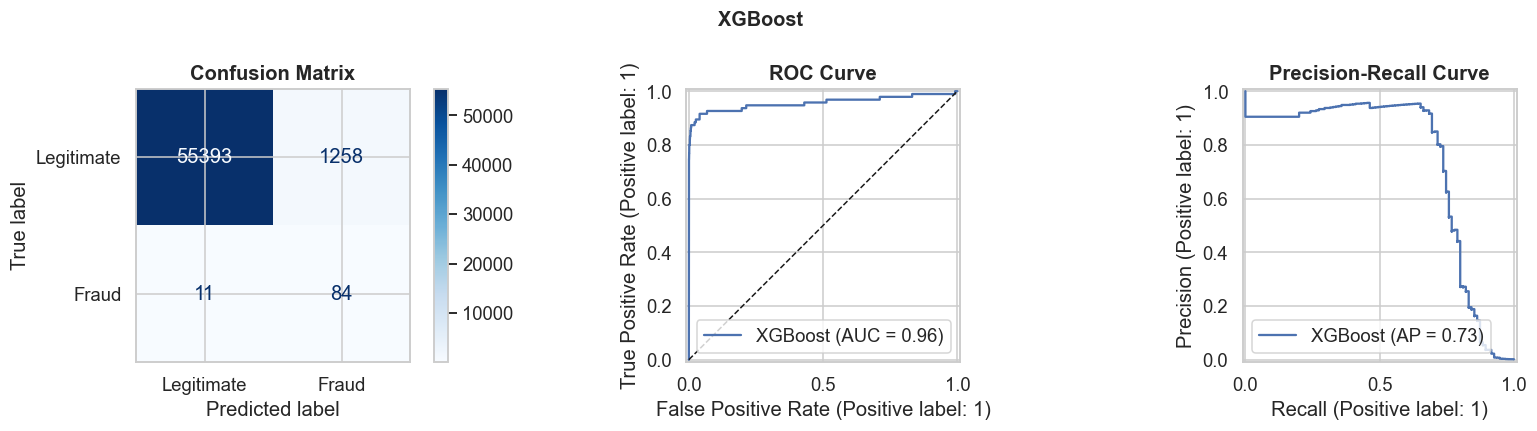

In [6]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale_pos:.1f}  (ratio of negatives to positives)')

xgb_pipeline = build_pipeline(
    XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        scale_pos_weight=scale_pos,
        eval_metric='aucpr',
        random_state=RANDOM_STATE,
        verbosity=0
    ),
    sampler=ADASYN(random_state=RANDOM_STATE)
)
xgb_pipeline.fit(X_train, y_train)
xgb_metrics, xgb_pred, xgb_prob = evaluate(xgb_pipeline, X_test, y_test,
                                             name='XGBoost')
plot_evaluation(y_test, xgb_pred, xgb_prob, 'XGBoost')


--- XGBoost + SMOTETomek (threshold=0.50) ---
  PR-AUC      : 0.7714
  ROC-AUC     : 0.964
  Recall      : 0.8632
  Precision   : 0.0756
  F1          : 0.139


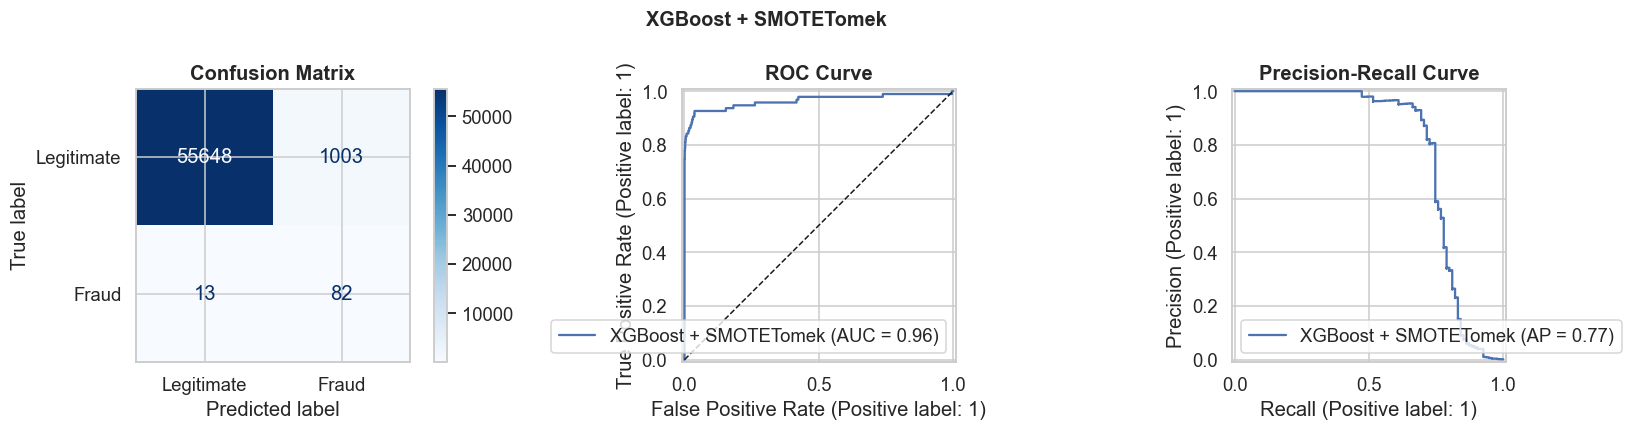

In [7]:
# XGBoost with SMOTETomek
xgb_st_pipeline = build_pipeline(
    XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        scale_pos_weight=scale_pos,
        eval_metric='aucpr',
        random_state=RANDOM_STATE,
        verbosity=0
    ),
    sampler=SMOTETomek(random_state=RANDOM_STATE)
)
xgb_st_pipeline.fit(X_train, y_train)
xgb_st_metrics, xgb_st_pred, xgb_st_prob = evaluate(
    xgb_st_pipeline, X_test, y_test, name='XGBoost + SMOTETomek'
)
plot_evaluation(y_test, xgb_st_pred, xgb_st_prob, 'XGBoost + SMOTETomek')

---
## 6. Isolation Forest (Anomaly Detection)

Isolation Forest is an unsupervised approach — it learns what normal looks like
and flags anything anomalous as fraud. No labels needed during training.

Contamination rate: 0.0017

--- Isolation Forest ---
  PR-AUC      : 0.1464
  ROC-AUC     : 0.9371
  Recall      : 0.2632
  Precision   : 0.2294
  F1          : 0.2451


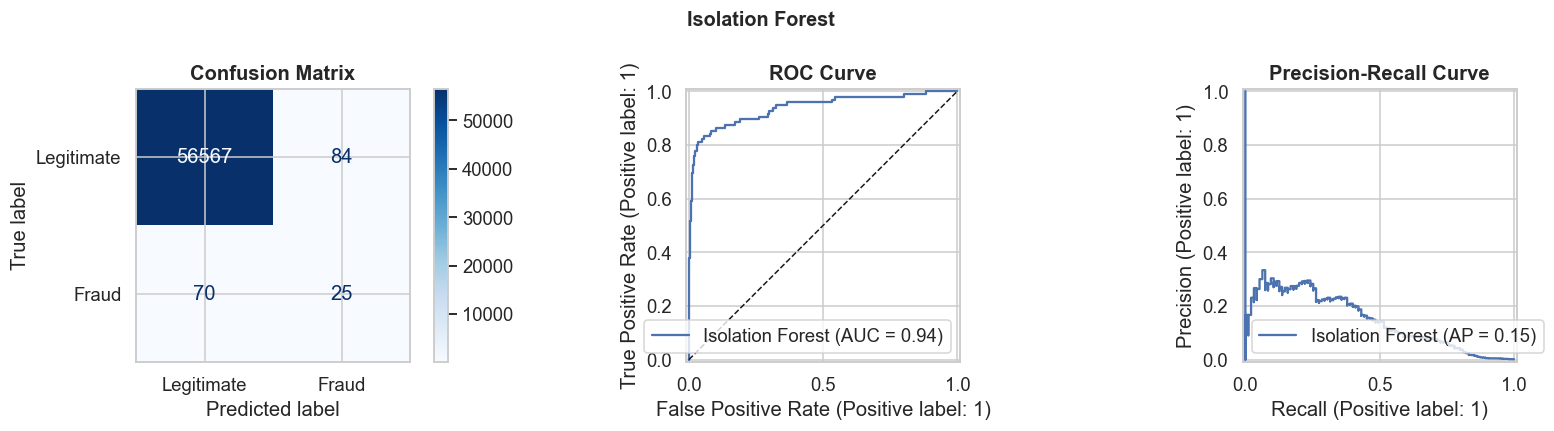

In [8]:
from sklearn.pipeline import Pipeline as SkPipeline

# Isolation Forest trains only on legitimate transactions
# contamination = expected fraction of anomalies
contamination = y_train.mean()
print(f'Contamination rate: {contamination:.4f}')

# Build preprocessor separately
iso_preprocessor = build_preprocessor()
X_train_t = iso_preprocessor.fit_transform(X_train)
X_test_t  = iso_preprocessor.transform(X_test)

# Train on ALL training data (unsupervised)
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=contamination,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
iso_forest.fit(X_train_t)

# Convert scores to probabilities
# IsolationForest returns anomaly scores — lower = more anomalous
iso_scores = iso_forest.decision_function(X_test_t)
# Flip and normalise to [0,1] probability-like scores
iso_prob   = 1 - (iso_scores - iso_scores.min()) / (iso_scores.max() - iso_scores.min())
iso_pred   = (iso_forest.predict(X_test_t) == -1).astype(int)  # -1 = anomaly = fraud

iso_metrics = {
    'PR-AUC':    round(average_precision_score(y_test, iso_prob), 4),
    'ROC-AUC':   round(roc_auc_score(y_test, iso_prob), 4),
    'Recall':    round(recall_score(y_test, iso_pred), 4),
    'Precision': round(precision_score(y_test, iso_pred, zero_division=0), 4),
    'F1':        round(f1_score(y_test, iso_pred, zero_division=0), 4),
}
print('\n--- Isolation Forest ---')
for k, v in iso_metrics.items():
    print(f'  {k:12s}: {v}')

plot_evaluation(y_test, iso_pred, iso_prob, 'Isolation Forest')

---
## 7. Model Comparison

In [9]:
results_df = pd.DataFrame({
    'Logistic Regression':   lr_metrics,
    'Random Forest':         rf_metrics,
    'XGBoost':               xgb_metrics,
    'XGBoost + SMOTETomek':  xgb_st_metrics,
    'Isolation Forest':      iso_metrics,
}).T.sort_values('PR-AUC', ascending=False)

print('=== Model Comparison (sorted by PR-AUC) ===')
results_df.style.background_gradient(cmap='RdYlGn', axis=0).format('{:.4f}')

=== Model Comparison (sorted by PR-AUC) ===


,PR-AUC,ROC-AUC,Recall,Precision,F1
Random Forest,0.8303,0.9669,0.7895,0.9375,0.8571
XGBoost + SMOTETomek,0.7714,0.9640,0.8632,0.0756,0.1390
XGBoost,0.7340,0.9565,0.8842,0.0626,0.1169
Logistic Regression,0.6911,0.9655,0.8737,0.0550,0.1035
Isolation Forest,0.1464,0.9371,0.2632,0.2294,0.2451


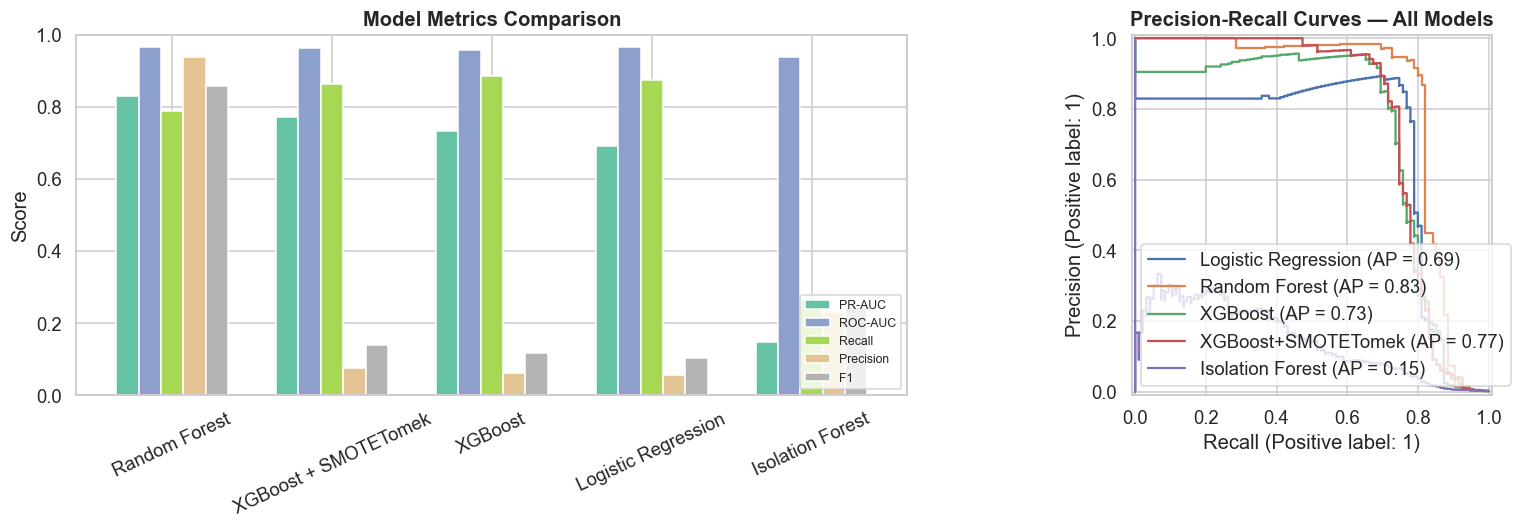

Best model by PR-AUC: Random Forest


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
results_df.plot(kind='bar', ax=axes[0], colormap='Set2',
                edgecolor='white', width=0.7)
axes[0].set_title('Model Metrics Comparison', fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=25)
axes[0].legend(loc='lower right', fontsize=8)

# PR curves all models
for prob, name, color in [
    (lr_prob,     'Logistic Regression',  '#3b82f6'),
    (rf_prob,     'Random Forest',        '#8b5cf6'),
    (xgb_prob,    'XGBoost',              '#f59e0b'),
    (xgb_st_prob, 'XGBoost+SMOTETomek',  '#10b981'),
    (iso_prob,    'Isolation Forest',     '#ef4444'),
]:
    PrecisionRecallDisplay.from_predictions(
        y_test, prob, ax=axes[1], name=name
    )
axes[1].set_title('Precision-Recall Curves — All Models', fontweight='bold')

plt.tight_layout()
plt.show()

best_model_name = results_df['PR-AUC'].idxmax()
print(f'Best model by PR-AUC: {best_model_name}')

---
## 8. Threshold Optimization

Default threshold is 0.5 — but this is rarely optimal for fraud detection.
We tune the threshold to minimise business cost.

In [11]:
# Use best supervised model for threshold analysis
# Map name to probability array
prob_map = {
    'Logistic Regression':  lr_prob,
    'Random Forest':        rf_prob,
    'XGBoost':              xgb_prob,
    'XGBoost + SMOTETomek': xgb_st_prob,
}
best_sup_name = results_df.drop('Isolation Forest')['PR-AUC'].idxmax()
best_prob     = prob_map[best_sup_name]
print(f'Running threshold optimization on: {best_sup_name}')

# Scan all thresholds
thresholds = np.linspace(0.01, 0.99, 300)
costs, recalls, precisions, f1s = [], [], [], []

for t in thresholds:
    y_pred_t = (best_prob >= t).astype(int)
    fn   = ((y_test == 1) & (y_pred_t == 0)).sum()
    fp   = ((y_test == 0) & (y_pred_t == 1)).sum()
    costs.append(fn * COST_FN + fp * COST_FP)
    recalls.append(recall_score(y_test, y_pred_t))
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    f1s.append(f1_score(y_test, y_pred_t, zero_division=0))

optimal_threshold = thresholds[np.argmin(costs)]
print(f'Optimal threshold: {optimal_threshold:.3f}')
print(f'Minimum cost:      {min(costs):,}')
print(f'Cost at 0.5:       {costs[np.argmin(abs(thresholds - 0.5))]:,}')

Running threshold optimization on: Random Forest
Optimal threshold: 0.072
Minimum cost:      1,372
Cost at 0.5:       2,005


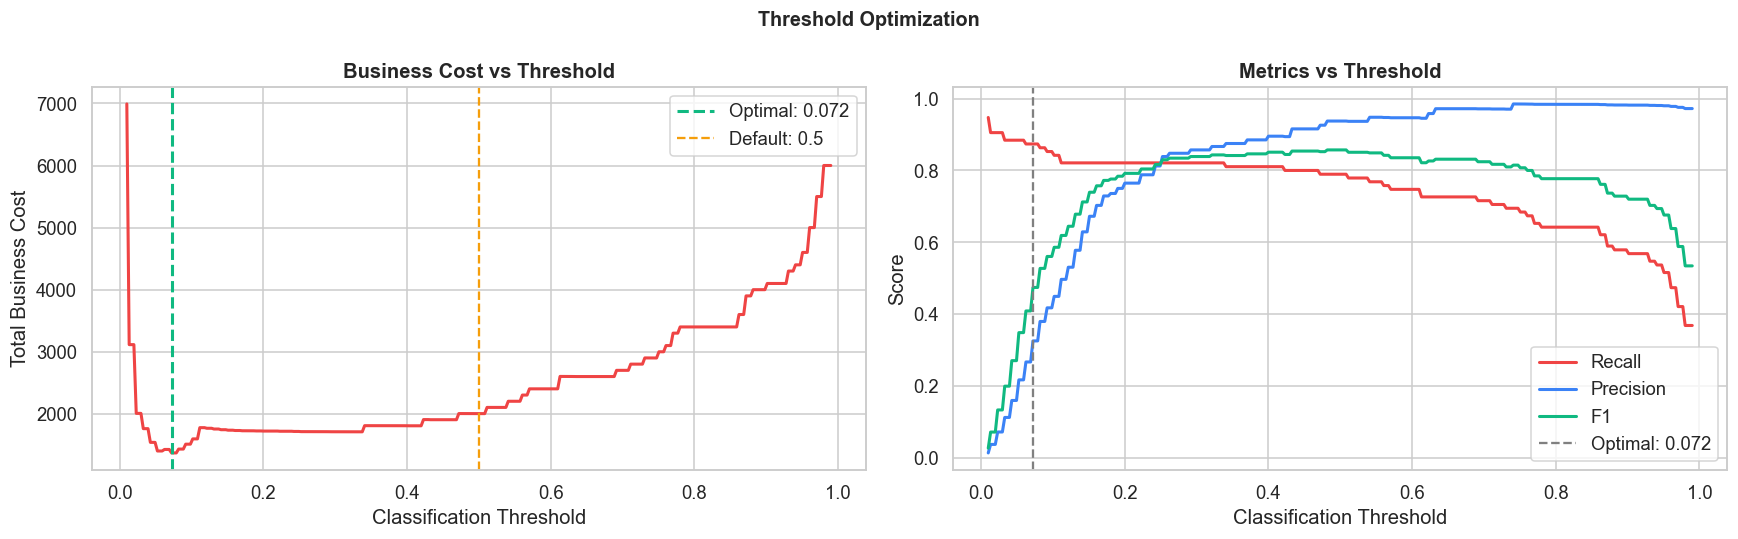

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Cost curve
axes[0].plot(thresholds, costs, color='#ef4444', linewidth=2)
axes[0].axvline(x=optimal_threshold, color='#10b981', linestyle='--',
                linewidth=2, label=f'Optimal: {optimal_threshold:.3f}')
axes[0].axvline(x=0.5, color='#f59e0b', linestyle='--',
                linewidth=1.5, label='Default: 0.5')
axes[0].set_title('Business Cost vs Threshold', fontweight='bold')
axes[0].set_xlabel('Classification Threshold')
axes[0].set_ylabel('Total Business Cost')
axes[0].legend()

# Recall, Precision, F1 vs threshold
axes[1].plot(thresholds, recalls,    label='Recall',    color='#ef4444', linewidth=2)
axes[1].plot(thresholds, precisions, label='Precision', color='#3b82f6', linewidth=2)
axes[1].plot(thresholds, f1s,        label='F1',        color='#10b981', linewidth=2)
axes[1].axvline(x=optimal_threshold, color='gray', linestyle='--',
                linewidth=1.5, label=f'Optimal: {optimal_threshold:.3f}')
axes[1].set_title('Metrics vs Threshold', fontweight='bold')
axes[1].set_xlabel('Classification Threshold')
axes[1].set_ylabel('Score')
axes[1].legend()

plt.suptitle('Threshold Optimization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# Compare default vs optimized threshold
pipeline_map = {
    'Logistic Regression':  lr_pipeline,
    'Random Forest':        rf_pipeline,
    'XGBoost':              xgb_pipeline,
    'XGBoost + SMOTETomek': xgb_st_pipeline,
}
best_pipeline = pipeline_map[best_sup_name]

print('Default threshold (0.5):')
default_metrics, _, _ = evaluate(best_pipeline, X_test, y_test,
                                  threshold=0.5, name=best_sup_name)

print(f'\nOptimized threshold ({optimal_threshold:.3f}):')
tuned_metrics, tuned_pred, tuned_prob = evaluate(
    best_pipeline, X_test, y_test,
    threshold=optimal_threshold, name=f'{best_sup_name} (Tuned)'
)

print('\nImprovement:')
for metric in ['PR-AUC', 'Recall', 'Precision', 'F1']:
    diff  = tuned_metrics[metric] - default_metrics[metric]
    arrow = 'up' if diff > 0 else 'down'
    print(f'  {metric:12s}: {arrow} {abs(diff):.4f}')

Default threshold (0.5):

--- Random Forest (threshold=0.50) ---
  PR-AUC      : 0.8303
  ROC-AUC     : 0.9669
  Recall      : 0.7895
  Precision   : 0.9375
  F1          : 0.8571

Optimized threshold (0.072):

--- Random Forest (Tuned) (threshold=0.07) ---
  PR-AUC      : 0.8303
  ROC-AUC     : 0.9669
  Recall      : 0.8737
  Precision   : 0.3255
  F1          : 0.4743

Improvement:
  PR-AUC      : down 0.0000
  Recall      : up 0.0842
  Precision   : down 0.6120
  F1          : down 0.3828


---
## 9. Cost-Sensitive Evaluation

In [14]:
print('=== Cost Analysis ===')
print(f'Assumptions:')
print(f'  Cost of missing a fraud (FN): €{COST_FN}')
print(f'  Cost of false alarm     (FP): €{COST_FP}')
print()

models_for_cost = {
    'Logistic Regression':  lr_prob,
    'Random Forest':        rf_prob,
    'XGBoost':              xgb_prob,
    'XGBoost + SMOTETomek': xgb_st_prob,
}

cost_results = []
for name, prob in models_for_cost.items():
    for t_name, t in [('Default (0.5)', 0.5), ('Optimized', optimal_threshold)]:
        y_pred_t = (prob >= t).astype(int)
        fn   = ((y_test == 1) & (y_pred_t == 0)).sum()
        fp   = ((y_test == 0) & (y_pred_t == 1)).sum()
        tp   = ((y_test == 1) & (y_pred_t == 1)).sum()
        cost = fn * COST_FN + fp * COST_FP
        cost_results.append({
            'Model':     name,
            'Threshold': t_name,
            'TP':        tp,
            'FN':        fn,
            'FP':        fp,
            'Total Cost': f'€{cost:,}'
        })

cost_df = pd.DataFrame(cost_results)
print(cost_df.to_string(index=False))

=== Cost Analysis ===
Assumptions:
  Cost of missing a fraud (FN): €100
  Cost of false alarm     (FP): €1

               Model     Threshold  TP  FN    FP Total Cost
 Logistic Regression Default (0.5)  83  12  1426     €2,626
 Logistic Regression     Optimized  90   5 12891    €13,391
       Random Forest Default (0.5)  75  20     5     €2,005
       Random Forest     Optimized  83  12   172     €1,372
             XGBoost Default (0.5)  84  11  1258     €2,358
             XGBoost     Optimized  87   8  3474     €4,274
XGBoost + SMOTETomek Default (0.5)  82  13  1003     €2,303
XGBoost + SMOTETomek     Optimized  88   7  3142     €3,842


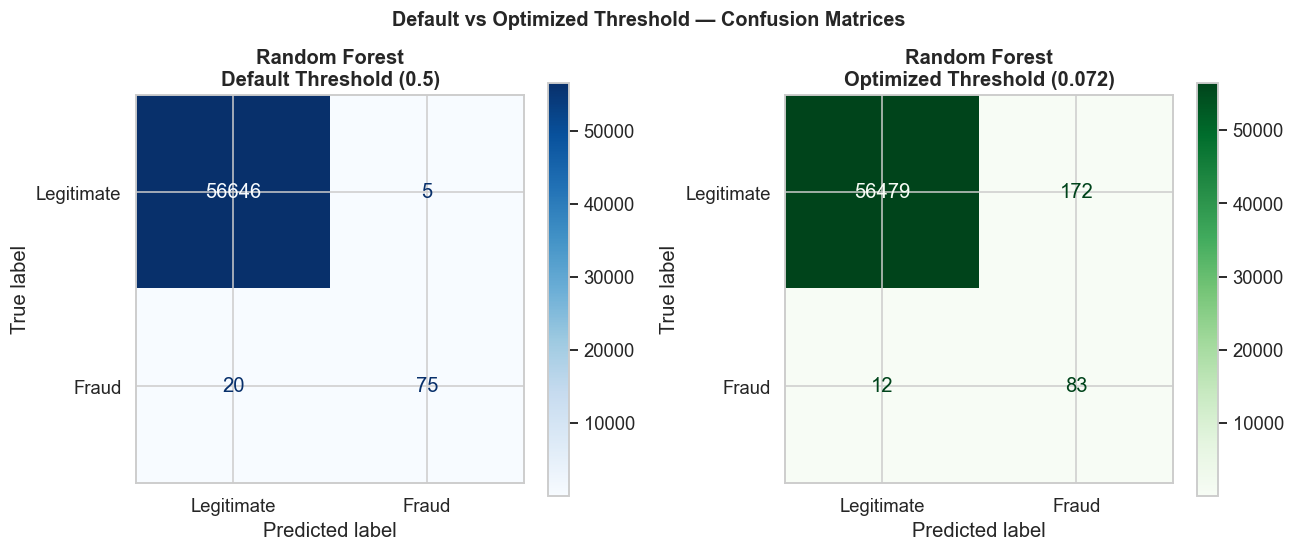

In [15]:
# Confusion matrix with optimized threshold
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Default
y_pred_default = (best_prob >= 0.5).astype(int)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_default,
    display_labels=['Legitimate', 'Fraud'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title(f'{best_sup_name}\nDefault Threshold (0.5)', fontweight='bold')

# Optimized
ConfusionMatrixDisplay.from_predictions(
    y_test, tuned_pred,
    display_labels=['Legitimate', 'Fraud'],
    cmap='Greens', ax=axes[1]
)
axes[1].set_title(f'{best_sup_name}\nOptimized Threshold ({optimal_threshold:.3f})',
                  fontweight='bold')

plt.suptitle('Default vs Optimized Threshold — Confusion Matrices',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. MLflow Tracking & Save Best Model

In [16]:
os.makedirs('../mlflow', exist_ok=True)
mlflow.set_tracking_uri('../mlflow')
mlflow.set_experiment('fraudshield')

log_items = [
    ('Logistic Regression',  lr_pipeline,     lr_metrics,     lr_prob),
    ('Random Forest',        rf_pipeline,     rf_metrics,     rf_prob),
    ('XGBoost',              xgb_pipeline,    xgb_metrics,    xgb_prob),
    ('XGBoost_SMOTETomek',   xgb_st_pipeline, xgb_st_metrics, xgb_st_prob),
]

for name, pipeline, metrics, _ in log_items:
    with mlflow.start_run(run_name=name):
        mlflow.log_metrics(metrics)
        mlflow.log_param('optimal_threshold', optimal_threshold)
        mlflow.sklearn.log_model(pipeline, artifact_path='model')
        print(f'Logged: {name}')

print('\nAll runs logged to MLflow')
print('View UI: mlflow ui --backend-store-uri ../mlflow')

2026/05/11 14:33:45 INFO mlflow.tracking.fluent: Experiment with name 'fraudshield' does not exist. Creating a new experiment.
2026/05/11 14:33:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 14:33:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/11 14:34:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logged: Logistic Regression


2026/05/11 14:34:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/11 14:34:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logged: Random Forest


2026/05/11 14:34:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/11 14:34:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logged: XGBoost


2026/05/11 14:34:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logged: XGBoost_SMOTETomek

All runs logged to MLflow
View UI: mlflow ui --backend-store-uri ../mlflow


In [17]:
os.makedirs('../models', exist_ok=True)

# Save best model
joblib.dump(best_pipeline, '../models/best_model_pipeline.pkl')

# Save optimal threshold
with open('../models/optimal_threshold.json', 'w') as f:
    json.dump({'threshold': float(optimal_threshold), 'model': best_sup_name}, f)

print(f'Best model saved:  models/best_model_pipeline.pkl')
print(f'Threshold saved:   models/optimal_threshold.json')
print(f'Model:             {best_sup_name}')
print(f'Optimal threshold: {optimal_threshold:.4f}')
print(f'PR-AUC:            {tuned_metrics["PR-AUC"]}')

Best model saved:  models/best_model_pipeline.pkl
Threshold saved:   models/optimal_threshold.json
Model:             Random Forest
Optimal threshold: 0.0723
PR-AUC:            0.8303


---
## Summary

In [ ]:
final_results = results_df.copy()
print('=== Final Model Leaderboard (by PR-AUC) ===')
print(final_results.to_string())

print("""
=================================================================
                      MODELING SUMMARY
=================================================================

  MODELS TRAINED
  - Logistic Regression  (baseline, class_weight=balanced)
  - Random Forest        (class_weight=balanced + SMOTE)
  - XGBoost              (scale_pos_weight + ADASYN)
  - XGBoost + SMOTETomek (scale_pos_weight + boundary cleaning)
  - Isolation Forest     (unsupervised anomaly detection)

  KEY DECISIONS
  - Primary metric: PR-AUC (not accuracy or ROC-AUC)
  - Threshold optimized for business cost minimization
  - RobustScaler used for outlier resistance

  NEXT STEP -> 04_explainability.ipynb
  - SHAP values for best model
  - Explain individual fraud predictions
  - Feature importance analysis
=================================================================
""")